In [1]:
import os
from PIL import Image

In [2]:
import kagglehub
import tensorflow as tf

In [3]:
from tensorflow.keras.preprocessing.image import array_to_img, img_to_array, load_img
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import array_to_img, img_to_array, load_img

In [4]:
from random import sample
import pandas as pd

In [5]:
from tensorflow.keras.utils import image_dataset_from_directory

In [6]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import layers, optimizers, callbacks

In [7]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model

In [8]:
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Trying out Shapley values with SHAP to explain bad predictions

In [ ]:
#! pip install shap
#! pip install opencv-python

In [ ]:
import cv2

In [ ]:
import json

from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

import shap

# load pre-trained model and choose two images to explain
model = ResNet50(weights="imagenet")


def f(X):
    tmp = X.copy()
    preprocess_input(tmp)
    return model(tmp)


X, y = shap.datasets.imagenet50()

# load the ImageNet class names as a vectorized mapping function from ids to names
url = "https://s3.amazonaws.com/deep-learning-models/image-models/imagenet_class_index.json"
with open(shap.datasets.cache(url)) as file:
    class_names = [v[1] for v in json.load(file).values()]

# define a masker that is used to mask out partitions of the input image, this one uses a blurred background
masker = shap.maskers.Image("inpaint_telea", X[0].shape)

# By default the Partition explainer is used for all  partition explainer
explainer = shap.Explainer(f, masker, output_names=class_names)

# here we use 500 evaluations of the underlying model to estimate the SHAP values
shap_values = explainer(X[1:3], max_evals=200, batch_size=50, outputs=shap.Explanation.argsort.flip[:1])
shap.image_plot(shap_values)

In [ ]:
X

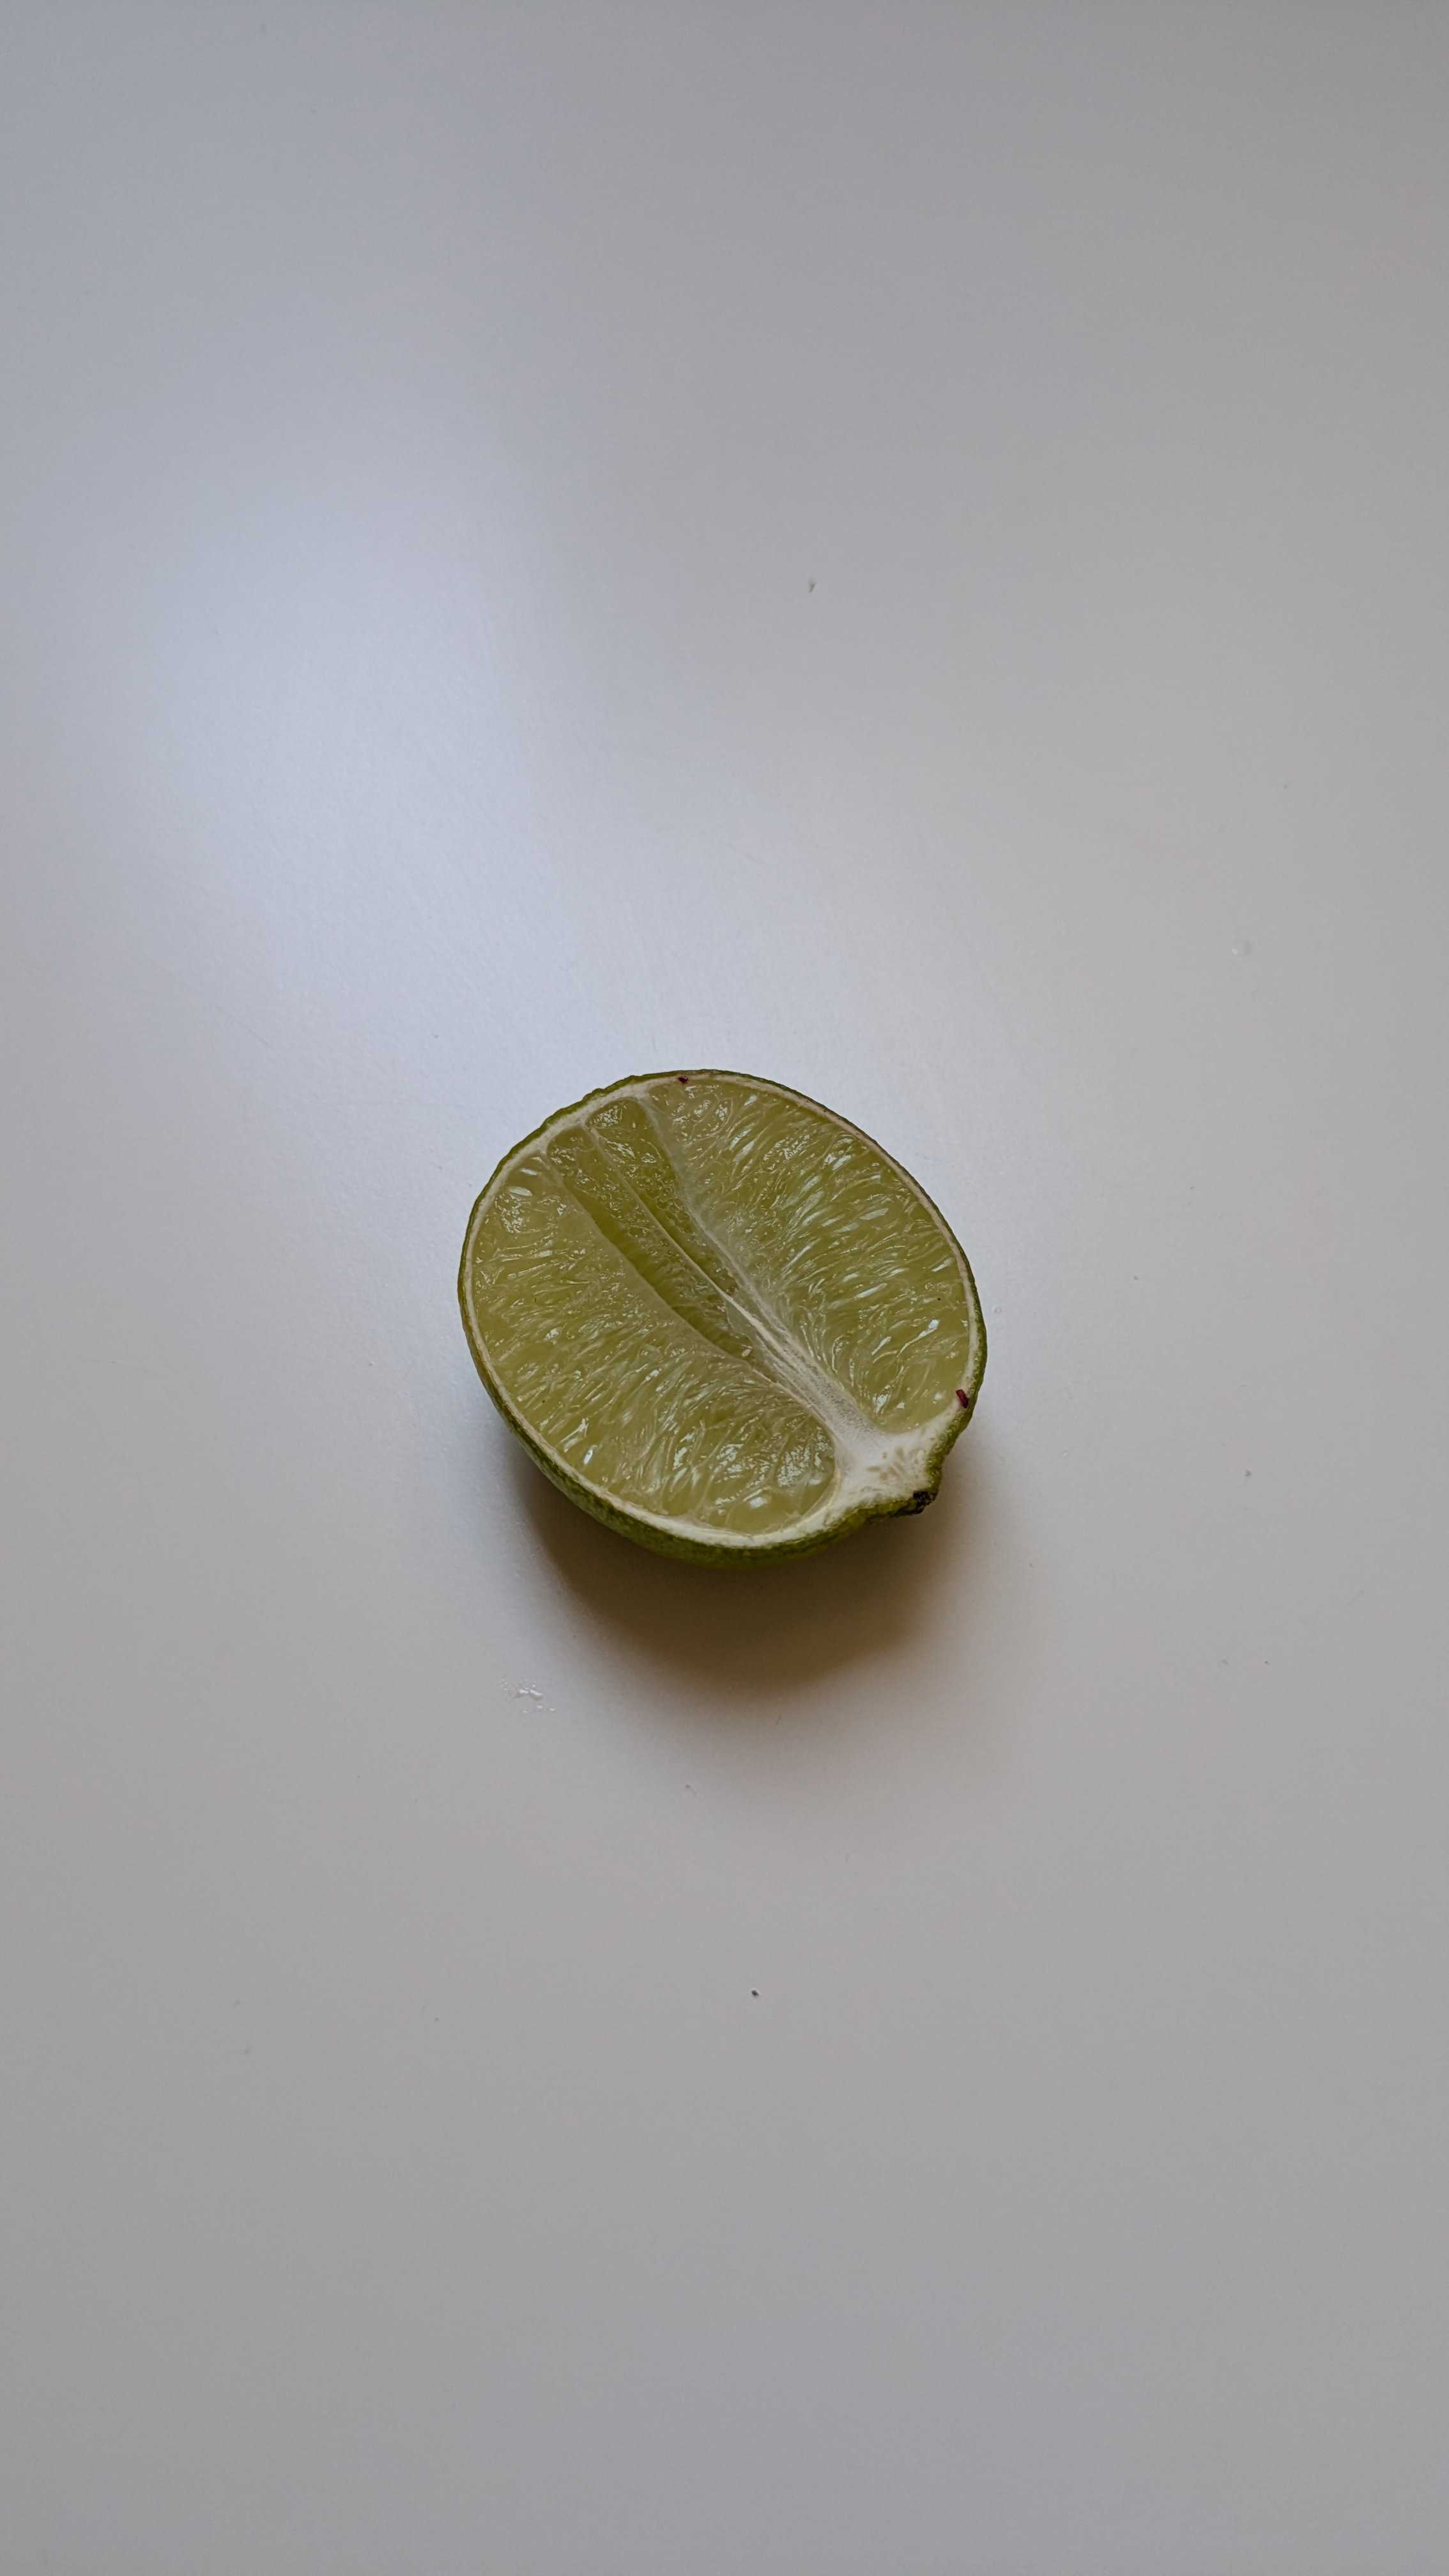

In [4]:
img = load_img("/kaggle/input/waste-test-set/test_data/trash_04.jpg")
img

  0%|          | 0/398 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:31, 31.35s/it]               


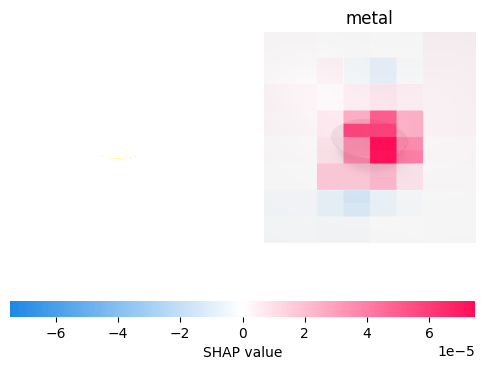

In [11]:
import cv2
import json

from tensorflow.keras.applications.resnet50 import ResNet50, preprocess_input

import shap

model = tf.keras.models.load_model('/kaggle/input/custom_resnet50_waste_ds_3_v2/tensorflow2/default/1/custom_resnet50_model_ds_3_v2.keras')

class_names = ['battery',
 'biological',
 'cardboard',
 'clothes',
 'glass',
 'metal',
 'paper',
 'plastic',
 'shoes',
 'trash']

img = load_img("/kaggle/input/waste-test-set/test_data/trash_04.jpg")

def f(X):
    tmp = X.copy()
    preprocess_input(tmp)
    return model(tmp)

# Resize to 384x384
img = img.resize((384, 384))

img = img_to_array(img) # don't divide by 255 here, the preprocess_input later takes care of that
x = img.reshape((-1, 384, 384, 3))

masker = shap.maskers.Image("inpaint_telea", x[0].shape)

# By default the Partition explainer is used for all  partition explainer
explainer = shap.Explainer(f, masker, output_names=class_names)

#img = load_img("/kaggle/input/waste-test-set/test_data/trash_04.jpg")

# here we use 500 evaluations of the underlying model to estimate the SHAP values
shap_values = explainer(x, max_evals=400, batch_size=32, outputs=shap.Explanation.argsort.flip[:1])
shap.image_plot(shap_values, show=False)
plt.savefig('/kaggle/working/lemon.png', format='png')

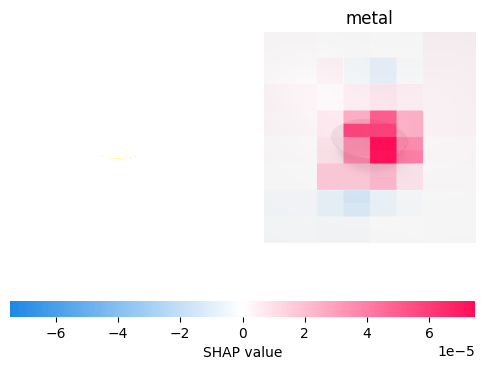

In [12]:
shap.image_plot(shap_values)

  0%|          | 0/398 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:23, 23.76s/it]               


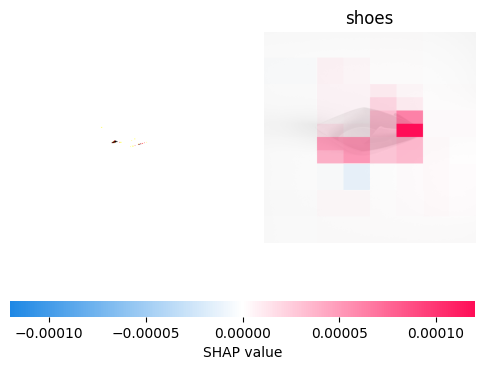

In [13]:
img = load_img("/kaggle/input/waste-test-set/test_data/cardboard_05.jpg")

# Resize to 384x384
img = img.resize((384, 384))

img = img_to_array(img) # don't divide by 255 here, the preprocess_input later takes care of that
x = img.reshape((-1, 384, 384, 3))

masker = shap.maskers.Image("inpaint_telea", x[0].shape)

# By default the Partition explainer is used for all  partition explainer
explainer = shap.Explainer(f, masker, output_names=class_names)

#img = load_img("/kaggle/input/waste-test-set/test_data/trash_04.jpg")

# here we use 500 evaluations of the underlying model to estimate the SHAP values
shap_values = explainer(x, max_evals=400, batch_size=32, outputs=shap.Explanation.argsort.flip[:1])
shap.image_plot(shap_values)

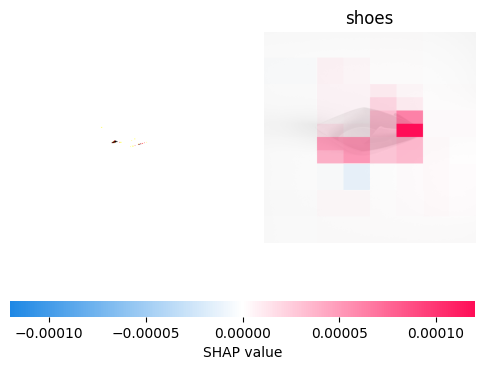

In [14]:
shap.image_plot(shap_values, show=False)
plt.savefig('/kaggle/working/cardboard_05.png', format='png')

  0%|          | 0/398 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:23, 23.25s/it]               


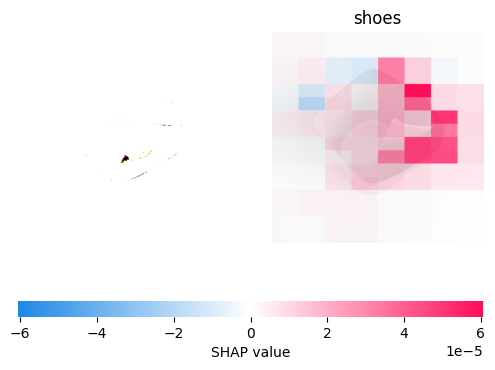

In [15]:
img = load_img("/kaggle/input/screenshot/Screenshot 2025-03-25 at 10.29.50.png")

# Resize to 384x384
img = img.resize((384, 384))

img = img_to_array(img) # don't divide by 255 here, the preprocess_input later takes care of that
x = img.reshape((-1, 384, 384, 3))

masker = shap.maskers.Image("inpaint_telea", x[0].shape)

# By default the Partition explainer is used for all  partition explainer
explainer = shap.Explainer(f, masker, output_names=class_names)

#img = load_img("/kaggle/input/waste-test-set/test_data/trash_04.jpg")

# here we use 500 evaluations of the underlying model to estimate the SHAP values
shap_values = explainer(x, max_evals=400, batch_size=32, outputs=shap.Explanation.argsort.flip[:1])
shap.image_plot(shap_values)

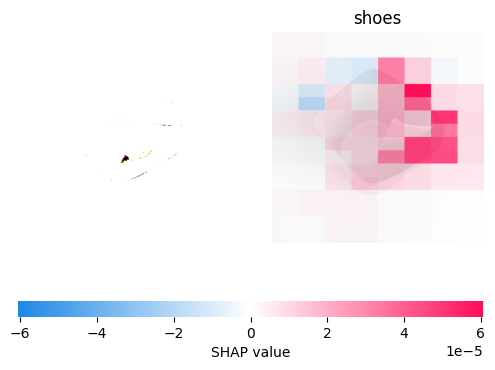

In [16]:
shap.image_plot(shap_values, show=False)
plt.savefig('/kaggle/working/cardboard_05_square.png', format='png')

  0%|          | 0/398 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:34, 34.45s/it]               


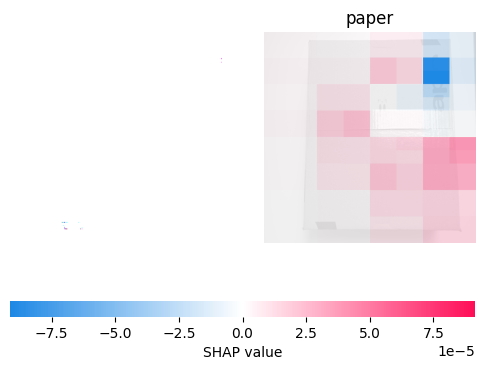

In [18]:
img = load_img("/kaggle/input/waste-test-set/test_data/cardboard_04.jpg")

# Resize to 384x384
img = img.resize((384, 384))

img = img_to_array(img) # don't divide by 255 here, the preprocess_input later takes care of that
x = img.reshape((-1, 384, 384, 3))

masker = shap.maskers.Image("inpaint_telea", x[0].shape)

# By default the Partition explainer is used for all  partition explainer
explainer = shap.Explainer(f, masker, output_names=class_names)

#img = load_img("/kaggle/input/waste-test-set/test_data/trash_04.jpg")

# here we use 500 evaluations of the underlying model to estimate the SHAP values
shap_values = explainer(x, max_evals=400, batch_size=32, outputs=shap.Explanation.argsort.flip[:1])
shap.image_plot(shap_values)

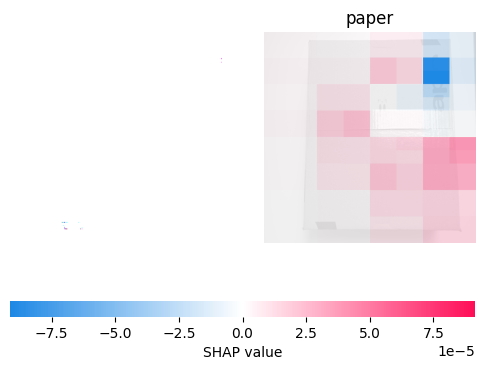

In [19]:
shap.image_plot(shap_values, show=False)
plt.savefig('/kaggle/working/cardboard_04.png', format='png')